In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib

from config import PROCESSED_DIR, FIGURES_DIR, SEED, TORCH_SEED
from pytorch_dataset import load_features, get_dataloaders

In [2]:
torch.manual_seed(TORCH_SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f8f8",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 12,
    "figure.dpi": 300,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.unicode_minus": False,
})

Device: cuda


In [3]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=None):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [128, 64, 32]
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.1))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_mlp(model, train_loader, test_loader, epochs=150, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss()

    train_losses, test_losses = [], []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * X_batch.size(0)
        train_losses.append(epoch_loss / len(train_loader.dataset))

        model.eval()
        epoch_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                epoch_loss += loss.item() * X_batch.size(0)
        test_losses.append(epoch_loss / len(test_loader.dataset))

        if (epoch + 1) % 30 == 0:
            print(f"    Epoch {epoch + 1:3d}/{epochs}  "
                  f"Train: {train_losses[-1]:.6f}  Test: {test_losses[-1]:.6f}")

    return train_losses, test_losses


def train_mlp_quiet(model, train_loader, epochs=150, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss()
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            loss = criterion(model(X_batch), y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    return model


def evaluate_model(model, test_loader):
    model.eval()
    y_true_all, y_pred_all = [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_pred = model(X_batch).cpu().numpy()
            y_true_all.append(y_batch.numpy())
            y_pred_all.append(y_pred)

    y_true = np.concatenate(y_true_all)
    y_pred = np.concatenate(y_pred_all)

    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f"\nMLP Results:")
    print(f" R2={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}")

    return y_true, y_pred, {"R2": r2, "RMSE": rmse, "MAE": mae}


def evaluate_quiet(model, test_loader):
    model.eval()
    y_true_all, y_pred_all = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_pred = model(X_batch).cpu().numpy()
            y_true_all.append(y_batch.numpy())
            y_pred_all.append(y_pred)
    y_true = np.concatenate(y_true_all)
    y_pred = np.concatenate(y_pred_all)
    return r2_score(y_true, y_pred)

In [4]:
def main():
    groups = ["G1", "G2", "G3"]
    print("Single-Seed Training")

    all_metrics = {}
    for group in groups:
        train_loader, test_loader, features = get_dataloaders(group, batch_size=512)
        input_dim = len(features)

        model = MLP(input_dim).to(device)
        train_losses, test_losses = train_mlp(
            model, train_loader, test_loader, epochs=150, lr=1e-3
        )

        y_true, y_pred, metrics = evaluate_model(model, test_loader)
        all_metrics[group] = metrics

        model_path = PROCESSED_DIR / f"model_MLP_{group}.pt"
        torch.save(model.state_dict(), model_path)
        print(f"  Saved: {model_path.name}")

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(train_losses, label="Train")
        ax.plot(test_losses, label="Test")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("MSE")
        ax.set_title(f"MLP Training: {group}")
        ax.legend()
        fig.tight_layout()
        plt.show()
        p = FIGURES_DIR / f"fig_mlp_training_{group}.png"
        fig.savefig(p, dpi=300, bbox_inches="tight")


    print("\nMLP Single-Seed Results:")
    results_df = pd.DataFrame(all_metrics).T
    results_df.index.name = "Group"
    print(results_df.round(4).to_string())
    results_df.to_csv(PROCESSED_DIR / "pytorch_mlp_results.csv")

    print("Multi-Seed Uncertainty Estimation")

    multi_seeds = [42, 123, 456, 789, 1024]
    multi_results = {g: [] for g in groups}

    for seed in multi_seeds:
        torch.manual_seed(seed)
        np.random.seed(seed)
        for group in groups:
            train_loader, test_loader, features = get_dataloaders(group, batch_size=512)
            model = MLP(len(features)).to(device)
            model = train_mlp_quiet(model, train_loader, epochs=150, lr=1e-3)
            r2 = evaluate_quiet(model, test_loader)
            multi_results[group].append(r2)
            print(f"seed={seed:5d}  {group}  R2={r2:.4f}")

    print("\nMLP Multi-Seed Summary:")
    print(f"  {'Group':8s}  {'R2_mean':>8s}  {'R2_std':>8s}  {'R2_min':>8s}  {'R2_max':>8s}")
    for group in groups:
        vals = multi_results[group]
        print(f"  {group:8s}  {np.mean(vals):8.4f}  {np.std(vals):8.4f}  "
              f"{min(vals):8.4f}  {max(vals):8.4f}")

    records = []
    for group in groups:
        vals = multi_results[group]
        records.append({
            "Method": "MLP", "Group": group,
            "R2_mean": np.mean(vals), "R2_std": np.std(vals),
            "R2_min": min(vals), "R2_max": max(vals),
        })
    multi_df = pd.DataFrame(records)
    multi_df.to_csv(PROCESSED_DIR / "mlp_multi_seed_results.csv", index=False)
    print(f"\nSaved to {PROCESSED_DIR / 'mlp_multi_seed_results.csv'}")

Single-Seed Training
  Group: G1  Features (2): ['mlotst', 'tos']
  Train: 40,515  Test: 12,987
  Batch size: 512  Train batches: 80
    Epoch  30/150  Train: 0.148287  Test: 0.141378
    Epoch  60/150  Train: 0.145796  Test: 0.142183
    Epoch  90/150  Train: 0.144915  Test: 0.141993
    Epoch 120/150  Train: 0.144514  Test: 0.142419
    Epoch 150/150  Train: 0.144886  Test: 0.142097

MLP Results:
 R2=0.1126  RMSE=0.3770  MAE=0.2705
  Saved: model_MLP_G1.pt


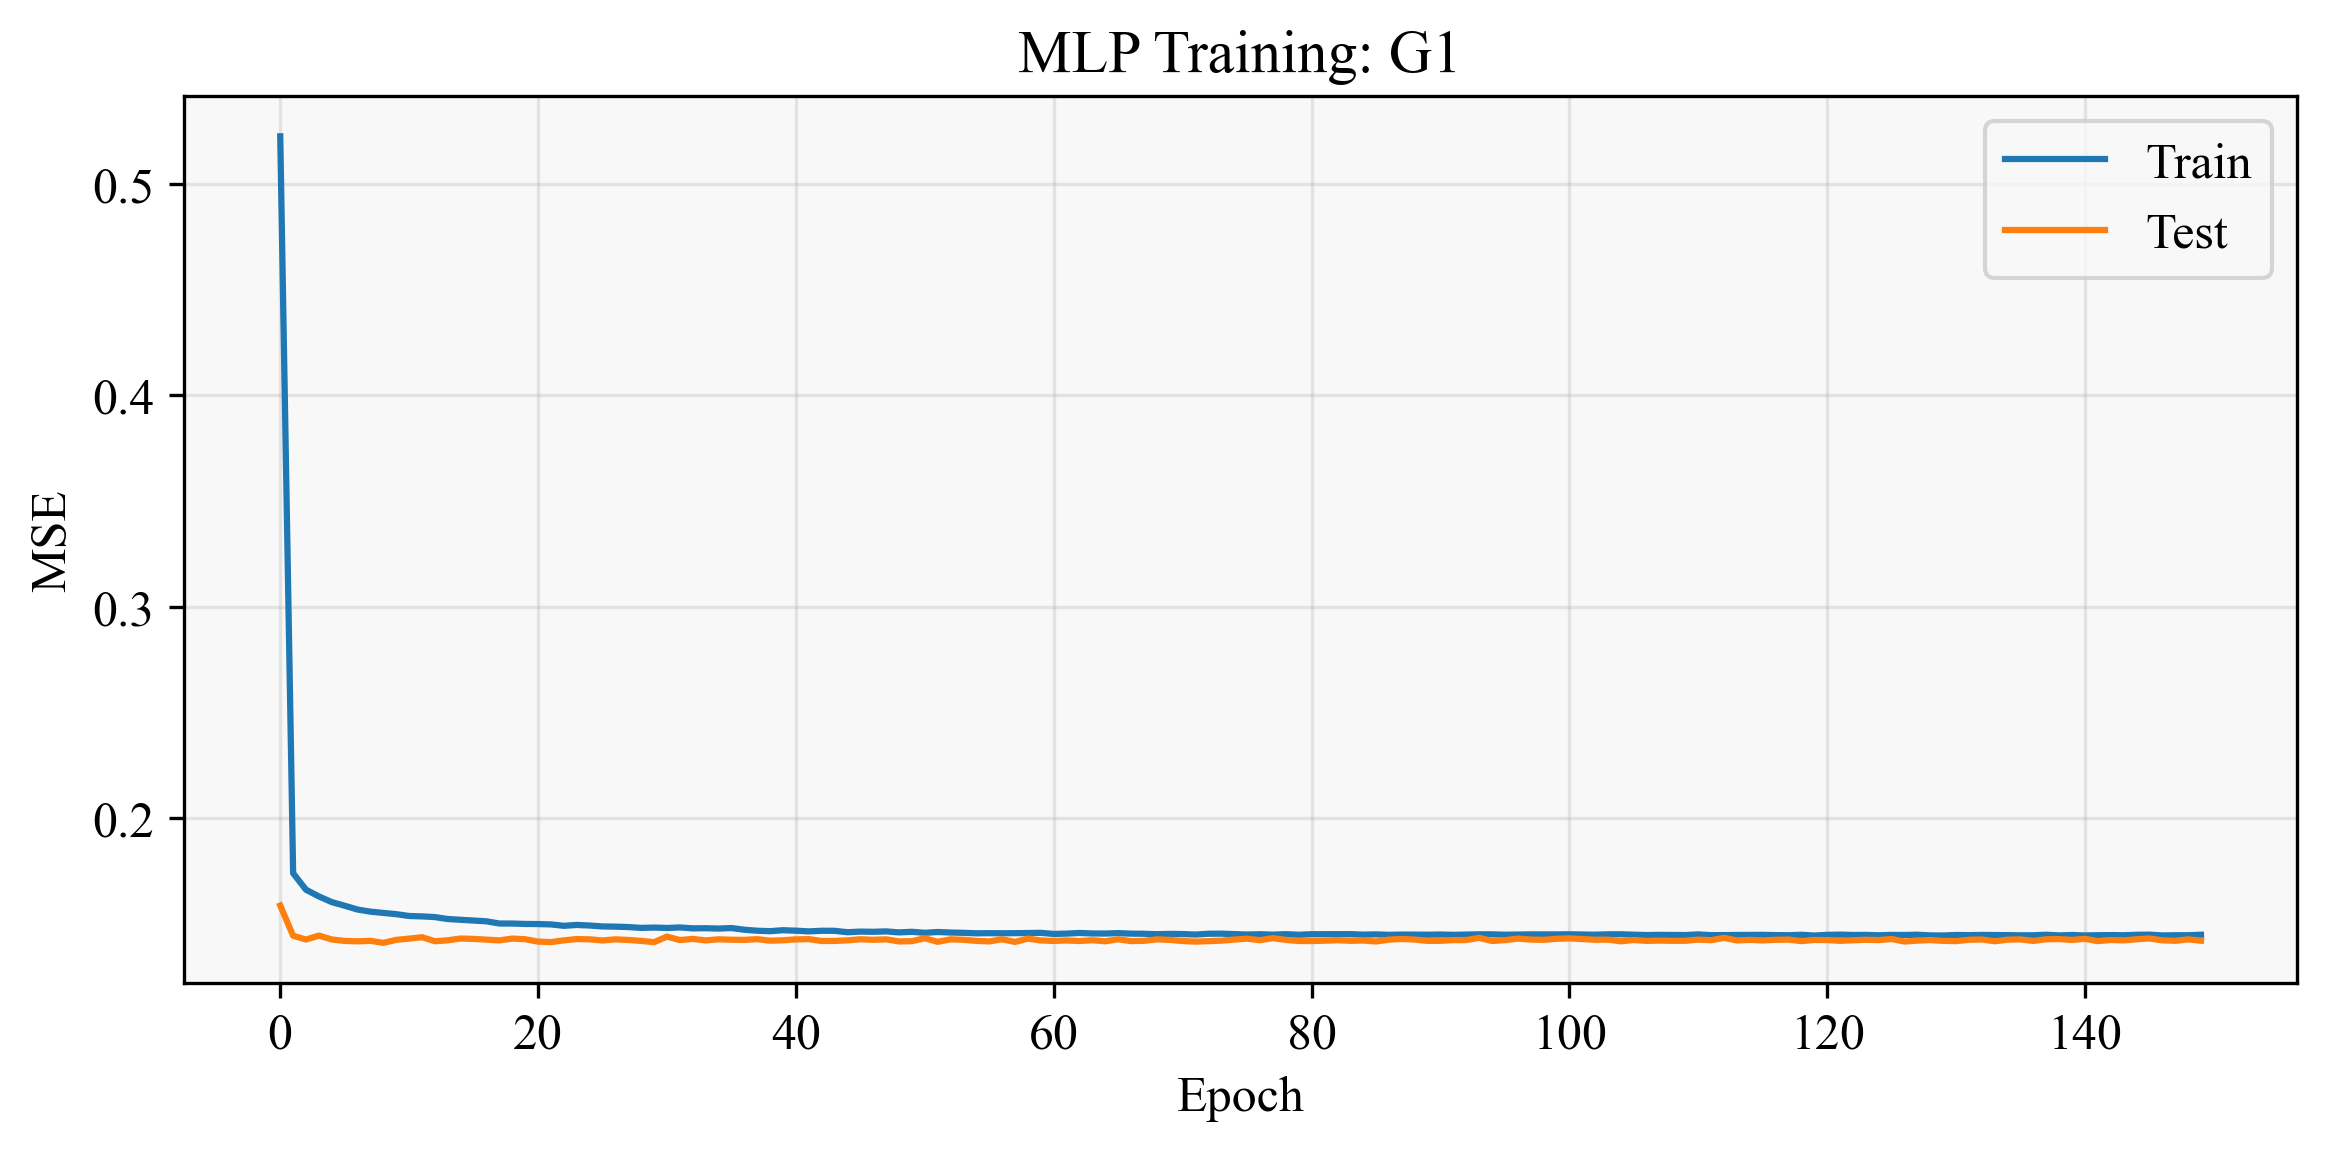

  Group: G2  Features (5): ['no3', 'po4', 'si', 'dfe', 'o2']
  Train: 40,515  Test: 12,987
  Batch size: 512  Train batches: 80
    Epoch  30/150  Train: 0.061507  Test: 0.058932
    Epoch  60/150  Train: 0.057813  Test: 0.057208
    Epoch  90/150  Train: 0.056166  Test: 0.056842
    Epoch 120/150  Train: 0.054896  Test: 0.056881
    Epoch 150/150  Train: 0.054498  Test: 0.056504

MLP Results:
 R2=0.6471  RMSE=0.2377  MAE=0.1771
  Saved: model_MLP_G2.pt


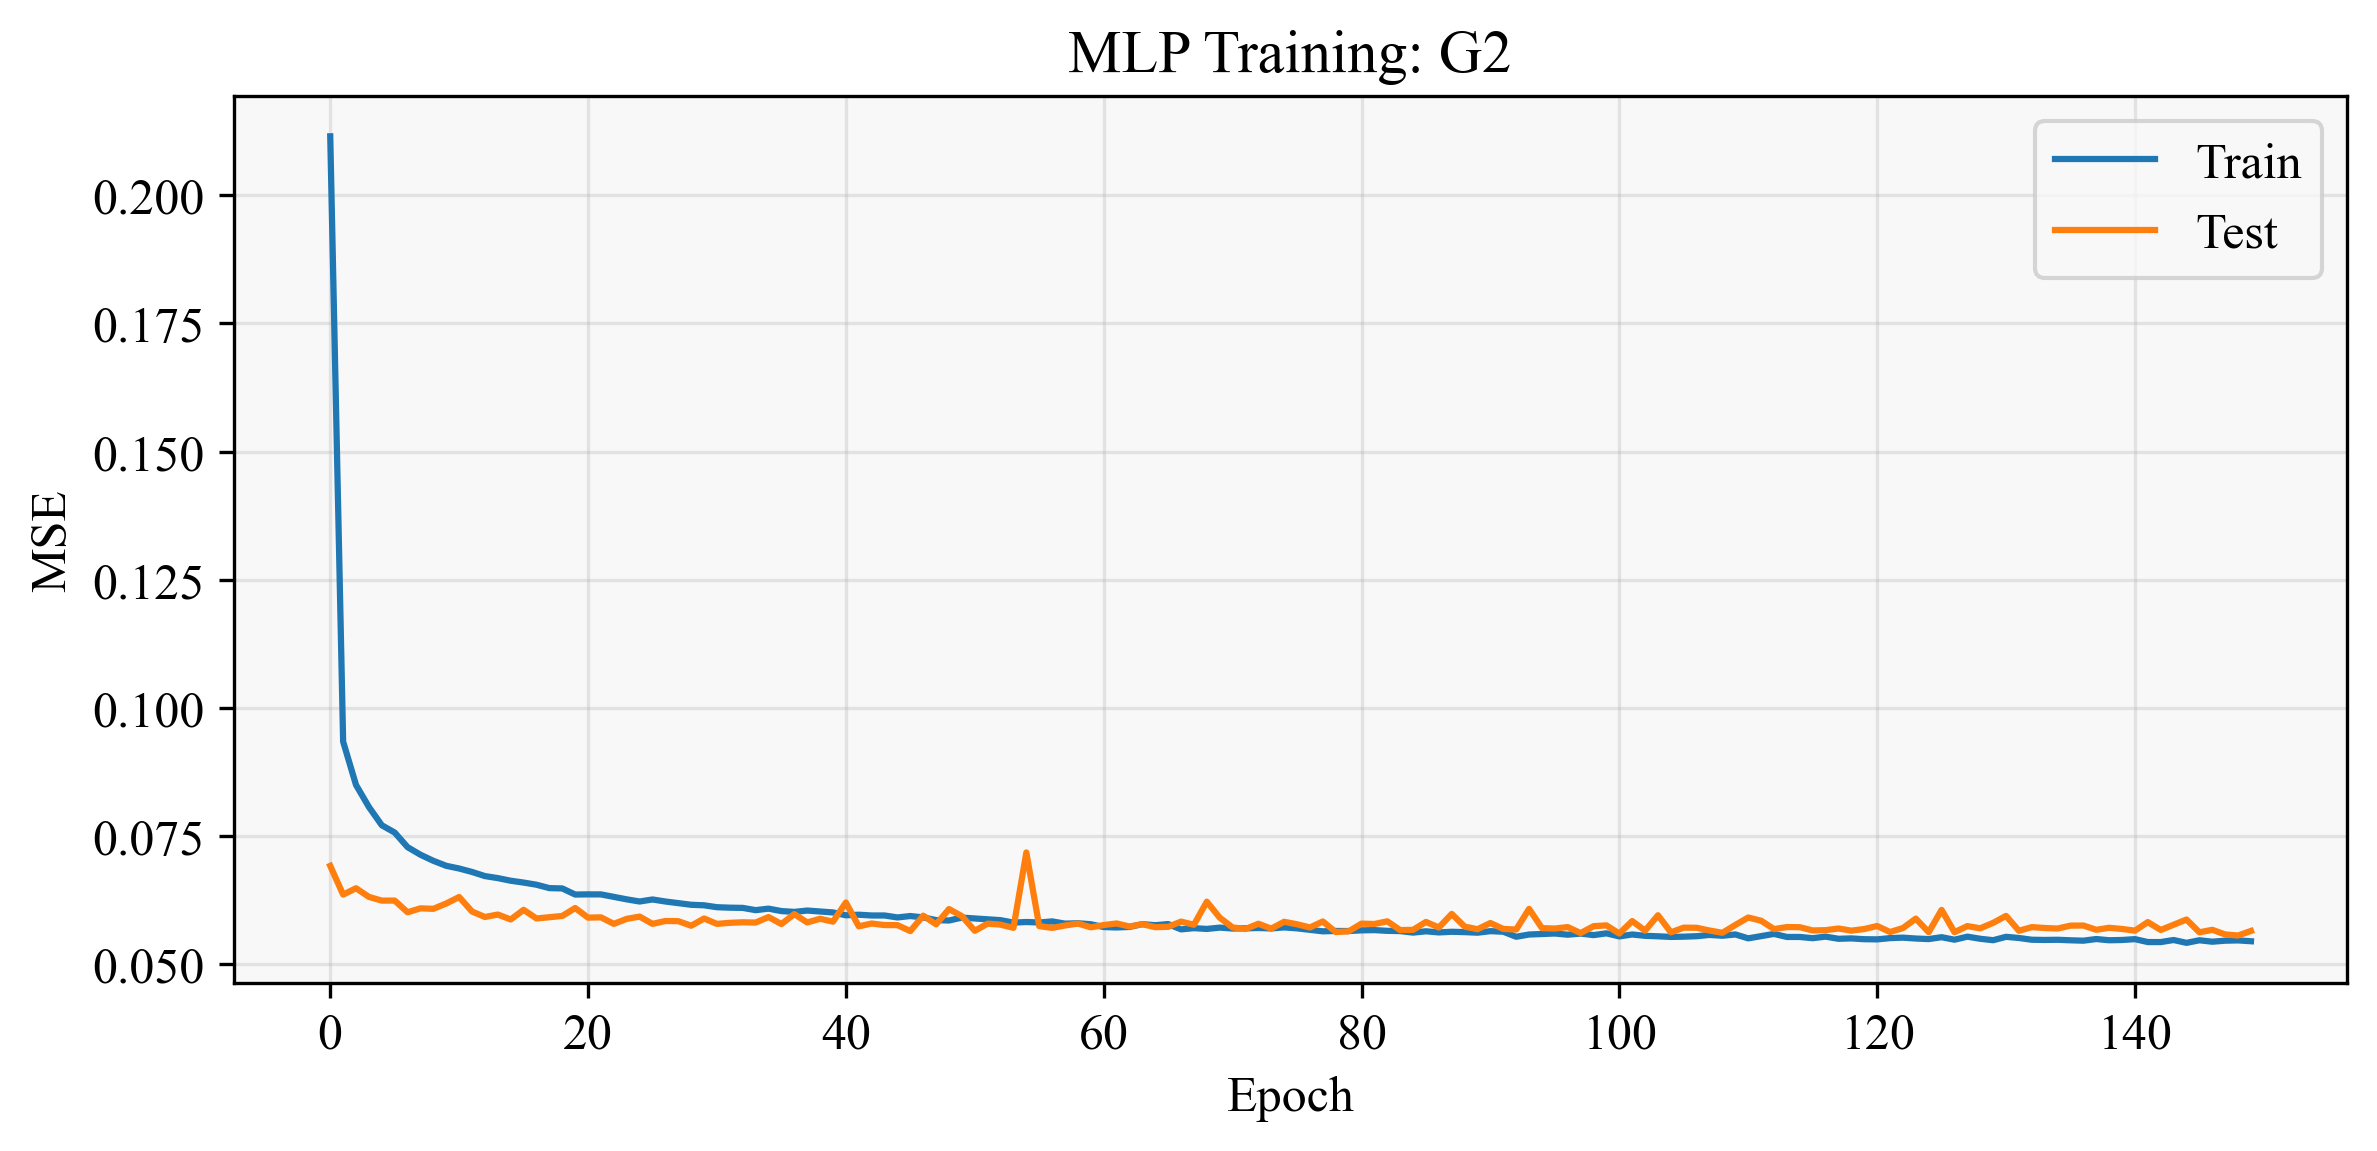

  Group: G3  Features (7): ['mlotst', 'tos', 'no3', 'po4', 'si', 'dfe', 'o2']
  Train: 40,515  Test: 12,987
  Batch size: 512  Train batches: 80
    Epoch  30/150  Train: 0.058196  Test: 0.055139
    Epoch  60/150  Train: 0.054350  Test: 0.052613
    Epoch  90/150  Train: 0.052806  Test: 0.053153
    Epoch 120/150  Train: 0.051268  Test: 0.052654
    Epoch 150/150  Train: 0.050483  Test: 0.051678

MLP Results:
 R2=0.6773  RMSE=0.2273  MAE=0.1657
  Saved: model_MLP_G3.pt


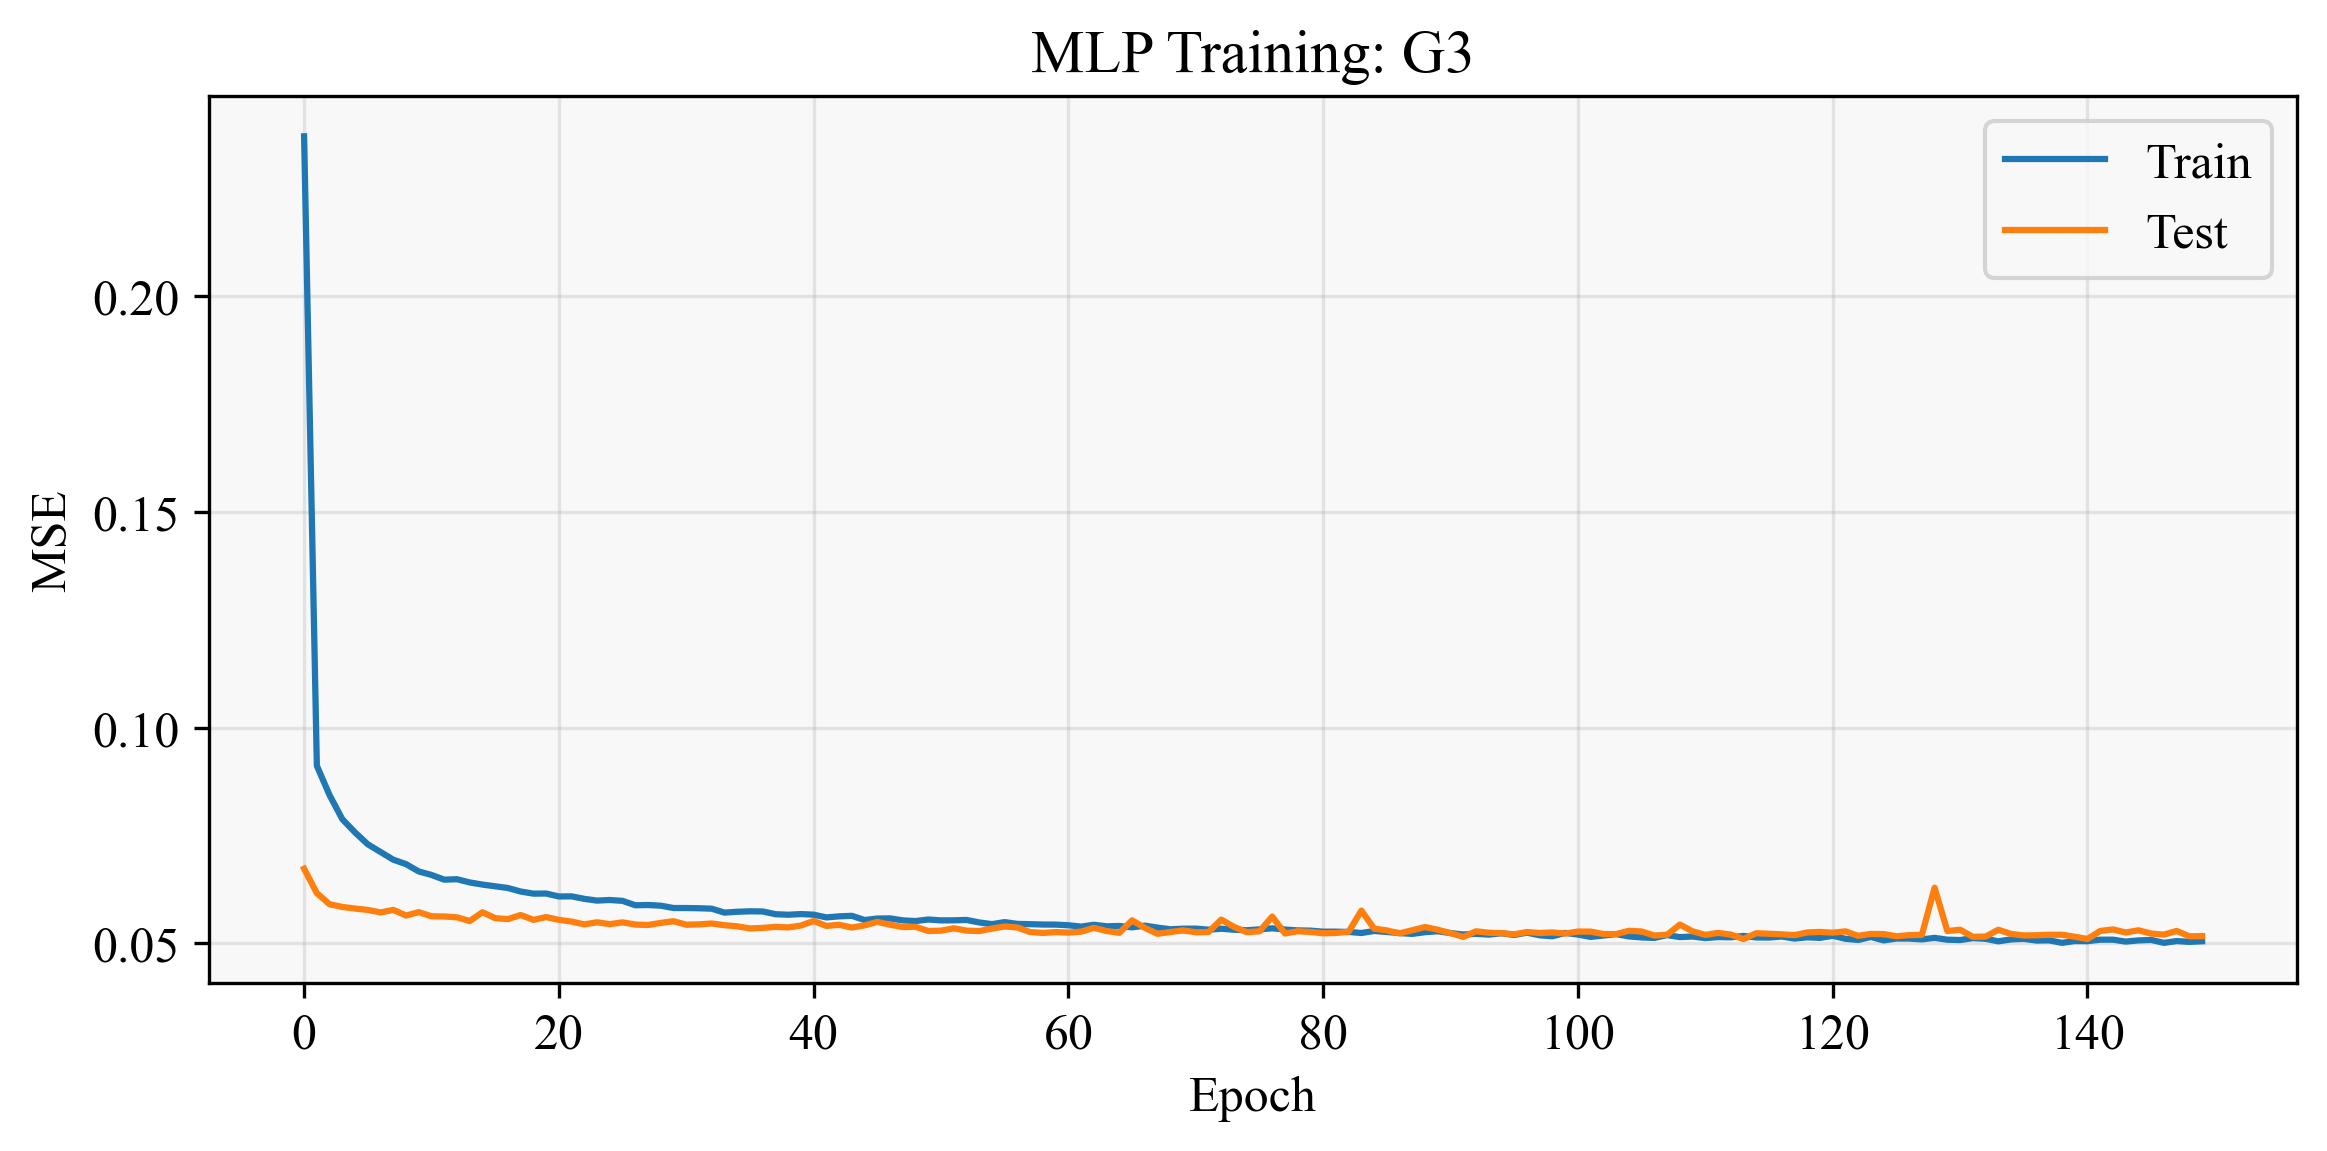


MLP Single-Seed Results:
           R2    RMSE     MAE
Group                        
G1     0.1126  0.3770  0.2705
G2     0.6471  0.2377  0.1771
G3     0.6773  0.2273  0.1657
Multi-Seed Uncertainty Estimation
  Group: G1  Features (2): ['mlotst', 'tos']
  Train: 40,515  Test: 12,987
  Batch size: 512  Train batches: 80
seed=   42  G1  R2=0.1126
  Group: G2  Features (5): ['no3', 'po4', 'si', 'dfe', 'o2']
  Train: 40,515  Test: 12,987
  Batch size: 512  Train batches: 80
seed=   42  G2  R2=0.6446
  Group: G3  Features (7): ['mlotst', 'tos', 'no3', 'po4', 'si', 'dfe', 'o2']
  Train: 40,515  Test: 12,987
  Batch size: 512  Train batches: 80
seed=   42  G3  R2=0.6743
  Group: G1  Features (2): ['mlotst', 'tos']
  Train: 40,515  Test: 12,987
  Batch size: 512  Train batches: 80
seed=  123  G1  R2=0.1087
  Group: G2  Features (5): ['no3', 'po4', 'si', 'dfe', 'o2']
  Train: 40,515  Test: 12,987
  Batch size: 512  Train batches: 80
seed=  123  G2  R2=0.6445
  Group: G3  Features (7): ['mlotst

In [5]:
if __name__ == "__main__":
    main()